# 1. Time Series Review
# Plot monthly mean discharge and concentration for two hydrological stations

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from statsmodels.tsa.stattools import acf, pacf

In [20]:
#Change root to your folder path
root = r'c:\Users\leoni\OneDrive\Documents\Master Umwelting ETH\Semester 2\Labor WRM\Asssignment 2\Assignment 2-20260512\DATA\DATA'
q1 = pd.read_csv(os.path.join(root,'Q_Diepoldsau_m3s.csv'), parse_dates=['timestamp']).set_index('timestamp')
q2 = pd.read_csv(os.path.join(root,'Q_Gisingen_1976-2023.csv'), parse_dates=['timestamp']).set_index('timestamp')
ssc1 = pd.read_csv(os.path.join(root,'SSC_Diepoldsau_gL.csv'), parse_dates=['timestamp']).set_index('timestamp')
ssc2 = pd.read_csv(os.path.join(root,'SSC_Gisingen_2003-2020.csv'), parse_dates=['timestamp']).set_index('timestamp')

In [21]:
q1 = q1.resample('ME').mean()
q2 = q2.resample('ME').mean()
ssc1 = ssc1.resample('ME').mean()
ssc2 = ssc2.resample('ME').mean()

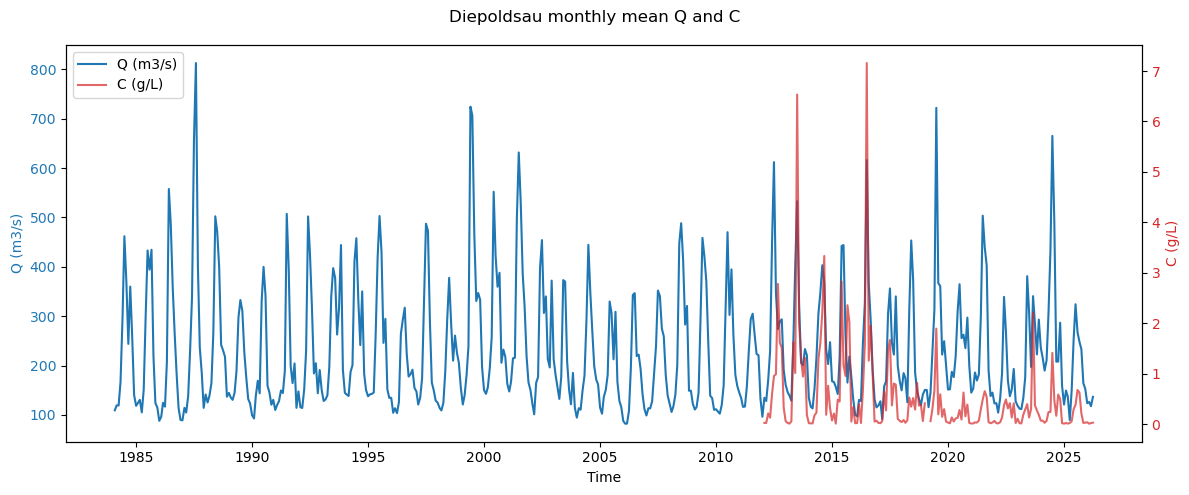

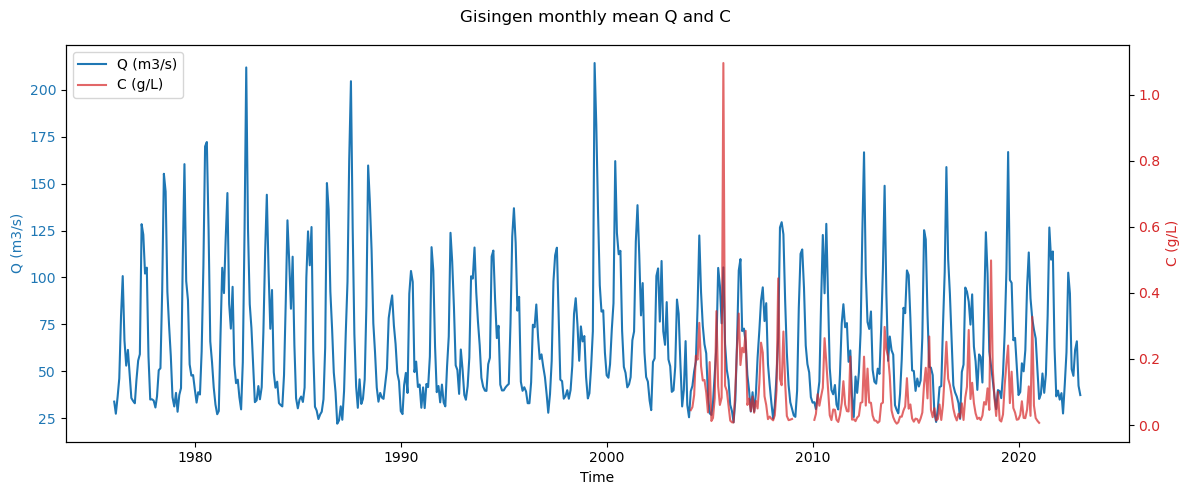

In [22]:
for station, dfQ, dfC in [('Diepoldsau', q1, ssc1), ('Gisingen', q2, ssc2)]:
    fig, ax = plt.subplots(figsize=(12,5))
    ax.plot(dfQ.index, dfQ['q_m3s'], label='Q (m3/s)', color='tab:blue')
    ax.set_xlabel('Time')
    ax.set_ylabel('Q (m3/s)', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    ax2 = ax.twinx()
    ax2.plot(dfC.index, dfC.iloc[:,0], label='C (g/L)', color='tab:red', alpha=0.7)
    ax2.set_ylabel('C (g/L)', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc='upper left')
    fig.suptitle(f'{station} monthly mean Q and C')
    fig.tight_layout()
    plt.show()

# 1.2 Stationarity test and trend removal
This section fits a linear trend to each station's monthly mean discharge series, tests the slope significance at the 5% level, removes any statistically significant trend, and verifies that the detrended series has zero mean and finite variance.

In [27]:
station_results = []
detrended_series = {}

for station, dfQ in [('Diepoldsau', q1), ('Gisingen', q2)]:
    y = dfQ['q_m3s'].dropna()
    x = np.arange(len(y))
    trend = linregress(x, y.values)
    pvalue = trend.pvalue
    slope_sig = pvalue < 0.05
    if slope_sig:
        detrended = y.values - (trend.intercept + trend.slope * x)
        detrend_method = 'linear trend'
    else:
        detrended = y.values - y.values.mean()
        detrend_method = 'mean'
    detrended_mean = detrended.mean()
    detrended_var = detrended.var(ddof=1)
    detrended_series[station] = pd.Series(detrended, index=y.index)
    station_results.append({
        'station': station,
        'n_points': len(y),
        'slope': trend.slope,
        'pvalue': pvalue,
        'significant': slope_sig,
        'detrend_method': detrend_method,
        'mean_after_detrend': detrended_mean,
        'variance_after_detrend': detrended_var,
    })
    print(f"{station}: n={len(y)}, slope={trend.slope:.6f}, p={pvalue:.4f}, significant={slope_sig}")
    print(f"    detrend method = {detrend_method}")
    print(f"    mean after detrending = {detrended_mean:.6e}")
    print(f"    variance after detrending = {detrended_var:.6e}\n")

station_results_df = pd.DataFrame(station_results)
station_results_df

Diepoldsau: n=507, slope=-0.019002, p=0.6136, significant=False
    detrend method = mean
    mean after detrending = -2.421731e-14
    variance after detrending = 1.533543e+04

Gisingen: n=564, slope=-0.007518, p=0.3952, significant=False
    detrend method = mean
    mean after detrending = 7.710145e-15
    variance after detrending = 1.166312e+03



,station,n_points,slope,pvalue,significant,detrend_method,mean_after_detrend,variance_after_detrend
0,Diepoldsau,507,-0.019002,0.613569,False,mean,-2.421731e-14,15335.425888
1,Gisingen,564,-0.007518,0.395156,False,mean,7.710145e-15,1166.312366


# Autocorrelation and partial autocorrelation analysis
This cell computes the empirical autocorrelation function (ACF) and the partial autocorrelation function (PACF) for the detrended discharge series of each station, together with approximate 95% confidence intervals.

In [ ]:
max_lag = 24
ci = 1.96 / np.sqrt(np.arange(1, max_lag + 1))

for station, series in detrended_series.items():
    acf_vals = acf(series, nlags=max_lag, fft=False, missing='drop')
    pacf_vals = pacf(series, nlags=max_lag, method='ywm')

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    lags = np.arange(len(acf_vals))

    axes[0].stem(lags, acf_vals, use_line_collection=True)
    axes[0].hlines([ci[0], -ci[0]], 0, max_lag, colors='gray', linestyles='dashed')
    axes[0].set_title(f'{station} ACF')
    axes[0].set_xlabel('Lag')
    axes[0].set_ylabel('ACF')

    axes[1].stem(lags, pacf_vals, use_line_collection=True)
    axes[1].hlines([ci[0], -ci[0]], 0, max_lag, colors='gray', linestyles='dashed')
    axes[1].set_title(f'{station} PACF')
    axes[1].set_xlabel('Lag')
    axes[1].set_ylabel('PACF')

    plt.tight_layout()
    plt.show()

    acf_df = pd.DataFrame({
        'lag': lags,
        'acf': acf_vals,
        'acf_lower': -ci[: len(acf_vals)],
        'acf_upper': ci[: len(acf_vals)],
        'pacf': pacf_vals,
        'pacf_lower': -ci[: len(pacf_vals)],
        'pacf_upper': ci[: len(pacf_vals)],
    })
    display(station)
    display(acf_df.head(10))